In [ ]:
#importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,  auc,recall_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score,confusion_matrix, precision_recall_curve, average_precision_score,roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
#reading the dataframe
df=pd.read_csv("./creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#display column names
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
#display of the different information linked to the dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Checking for missing data
print(df.isnull().sum())

# Checking the distribution of classes
counts = df['Class'].value_counts()
print(counts)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class
0    284315
1       492
Name: count, dtype: int64


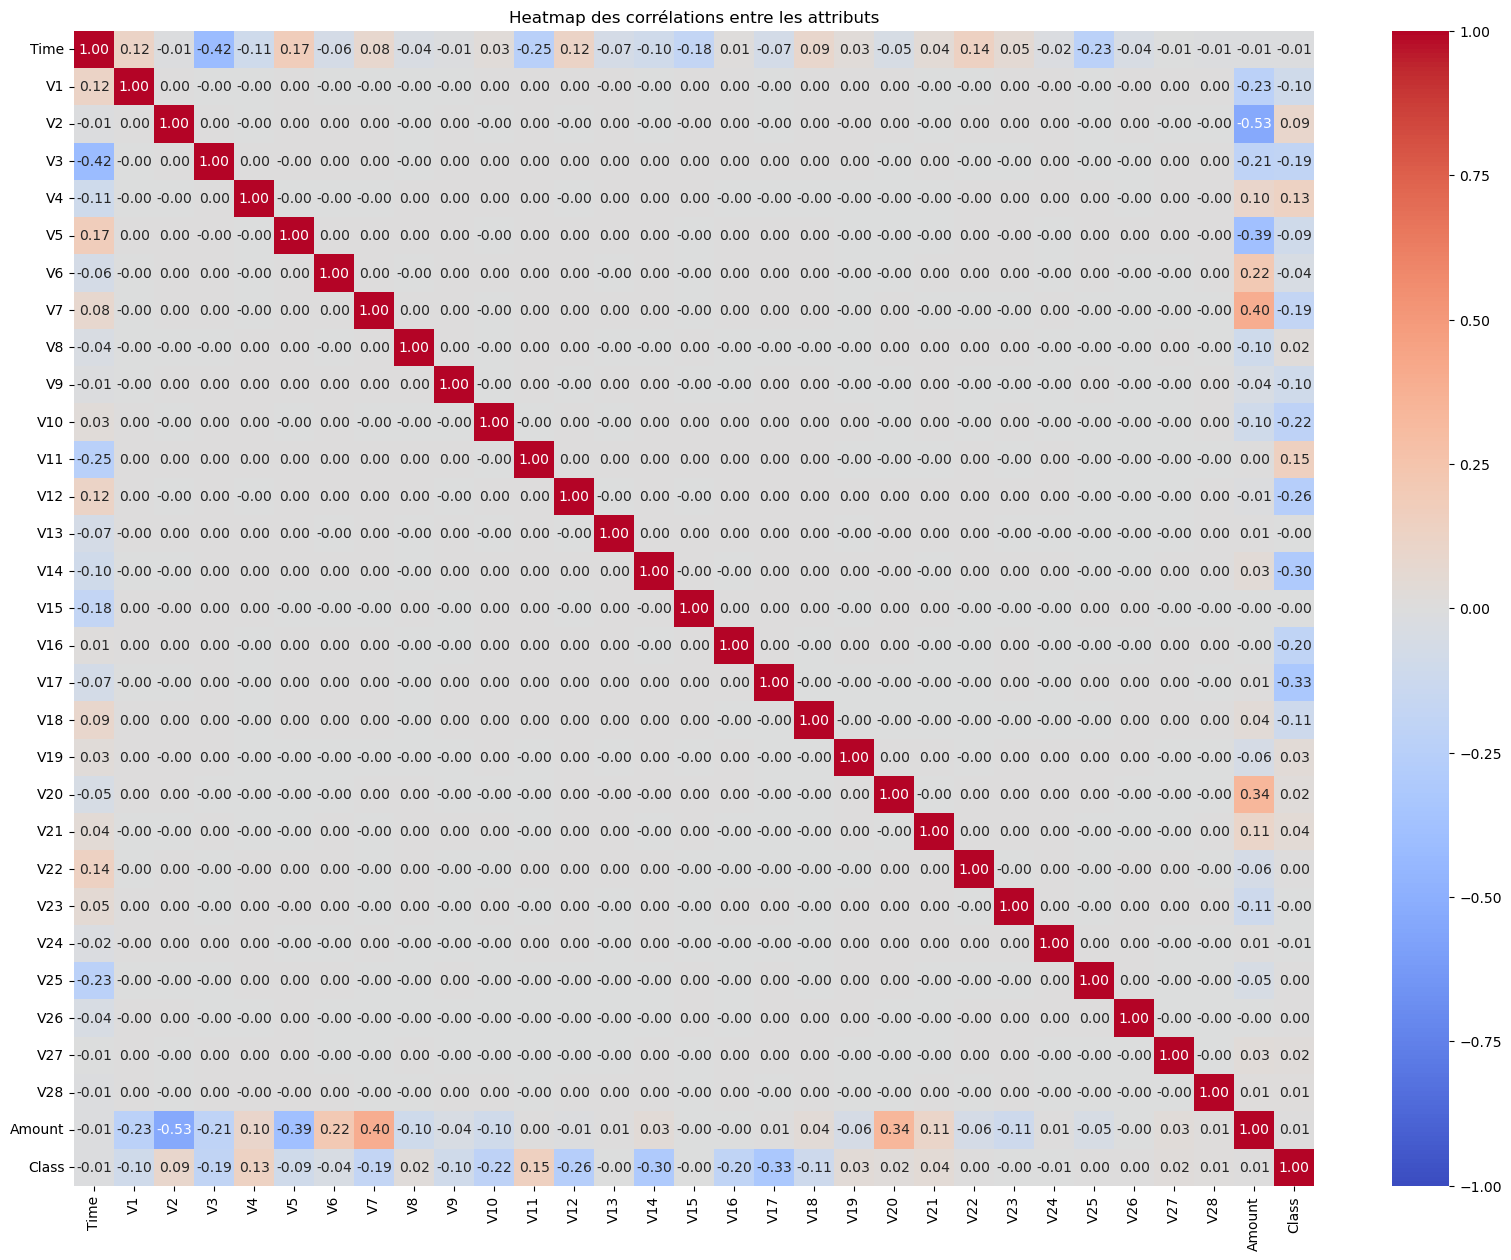

In [ ]:
# Calculation of the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(20, 15))  # Adjust the size of the figure if necessary
sns.heatmap(correlation_matrix, 
            annot=True,            # Displays correlation values ​​on the heatmap
            fmt=".2f",             # Format to display decimals
            cmap='coolwarm',       # Color palette
            vmin=-1, vmax=1)       # Limits for correlation values ​​(-1 to 1)

plt.title("Heatmap of correlations between attributes")
plt.show()

NORMALISATION

In [ ]:

# Normalization of the Amount column
scaler_amount = StandardScaler()
df['Amount'] = scaler_amount.fit_transform(df[['Amount']])

# Normalization of the Time column
scaler_time = StandardScaler()
df['Time'] = scaler_time.fit_transform(df[['Time']])

In [ ]:
#Separation of data into explanatory and target variables
X = df.drop('Class', axis=1)
y = df['Class']


DATA REBALANCING

In [ ]:
# Data rebalancing with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Checking the new proportions
from collections import Counter
print("Distribution after SMOTE :", Counter(y_resampled))

Répartition après SMOTE : Counter({0: 284315, 1: 284315})


In [ ]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)


LOGISTIC REGRESSION

Logistic Regression Metrics:
Accuracy: 0.9484, Recall: 0.9217, Precision: 0.9737, F1-Score: 0.9470, MCC: 0.8981, AUC: 0.9895


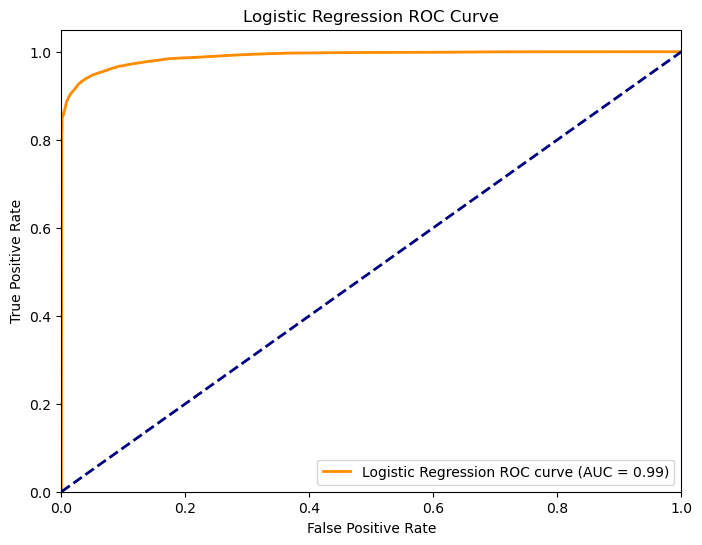

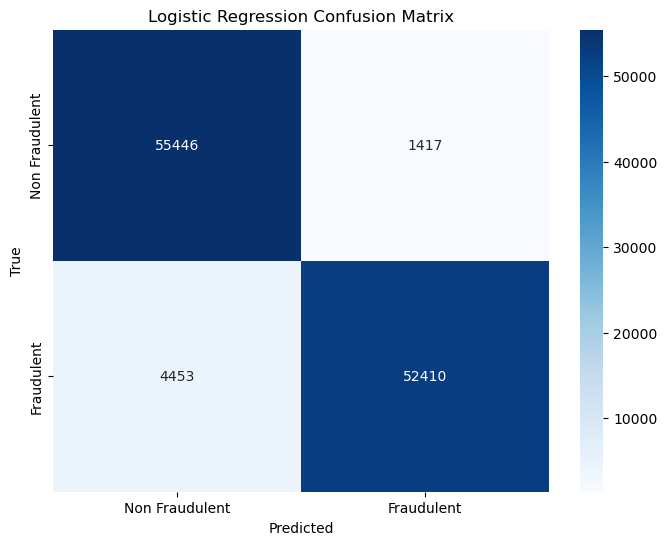

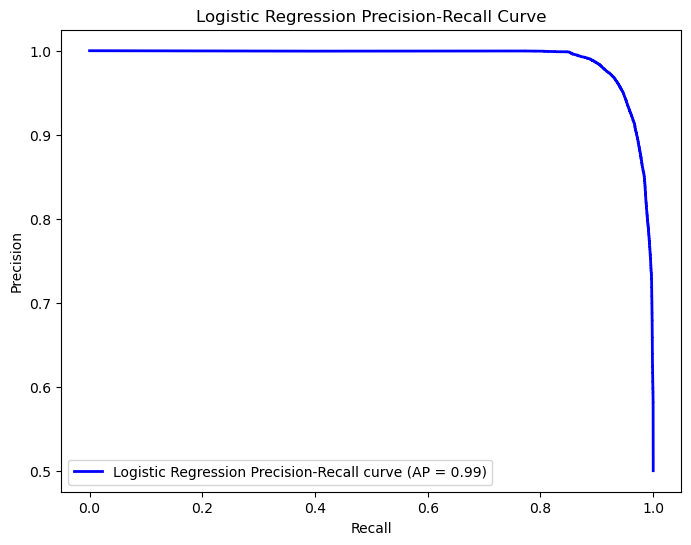

In [ ]:
# Train the Logistic Regression model
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Making predictions
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
mcc_lr = matthews_corrcoef(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Show results
print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_lr:.4f}, Recall: {recall_lr:.4f}, Precision: {precision_lr:.4f}, F1-Score: {f1_lr:.4f}, MCC: {mcc_lr:.4f}, AUC: {auc_lr:.4f}")
# Visualization 1: ROC and AUC curve
def plot_roc_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Visualization 2: Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraudulent', 'Fraudulent'], yticklabels=['Non Fraudulent', 'Fraudulent'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Visualisation 3: Courbe de précision-rappel
def plot_precision_recall_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'{model_name} Precision-Recall curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

# Plotting curves and matrices for the Logistic Regression model
plot_roc_curve(lr, X_test, y_test, 'Logistic Regression')
plot_confusion_matrix(lr, X_test, y_test, 'Logistic Regression')
plot_precision_recall_curve(lr, X_test, y_test, 'Logistic Regression')

WITH ADABOOST

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Logistic Regression with AdaBoost Metrics:
Accuracy: 0.9395
Recall: 0.9039
Precision: 0.9731
F1-Score: 0.9372
MCC: 0.8812
AUC: 0.9846


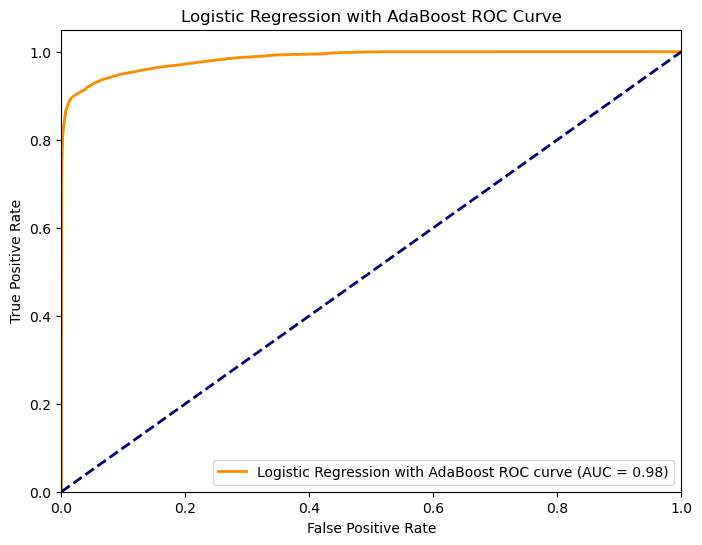

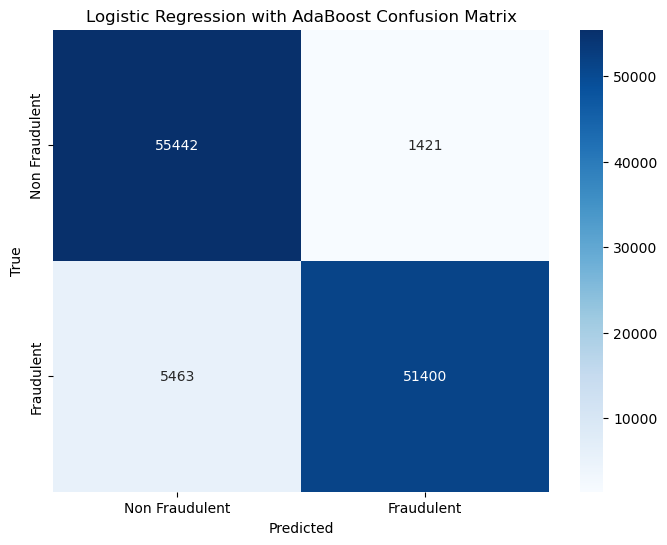

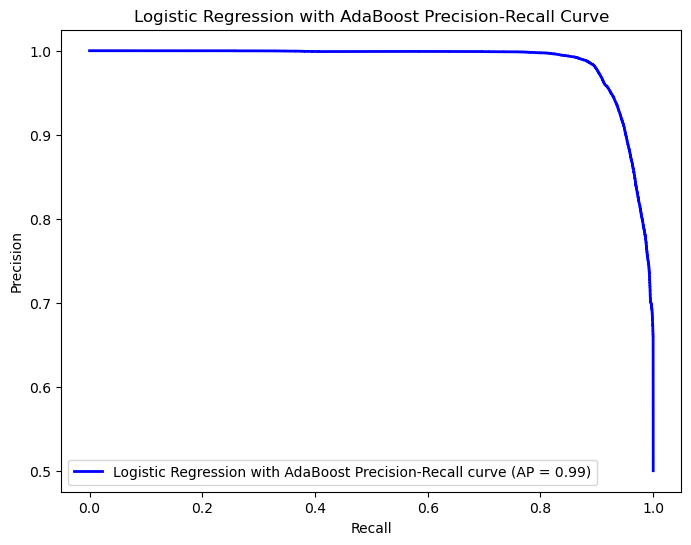

In [ ]:
# Train the Logistic Regression model with AdaBoost
lr_base = LogisticRegression(random_state=42)
ada_lr = AdaBoostClassifier(estimator=lr_base, n_estimators=50, random_state=42)
ada_lr.fit(X_train, y_train)

# Making predictions
y_pred_ada_lr = ada_lr.predict(X_test)
y_proba_ada_lr = ada_lr.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_ada_lr = accuracy_score(y_test, y_pred_ada_lr)
recall_ada_lr = recall_score(y_test, y_pred_ada_lr)
precision_ada_lr = precision_score(y_test, y_pred_ada_lr)
f1_ada_lr = f1_score(y_test, y_pred_ada_lr)
mcc_ada_lr = matthews_corrcoef(y_test, y_pred_ada_lr)
auc_ada_lr = roc_auc_score(y_test, y_proba_ada_lr)

# Show results
print("Logistic Regression with AdaBoost Metrics:")
print(f"Accuracy: {accuracy_ada_lr:.4f}")
print(f"Recall: {recall_ada_lr:.4f}")
print(f"Precision: {precision_ada_lr:.4f}")
print(f"F1-Score: {f1_ada_lr:.4f}")
print(f"MCC: {mcc_ada_lr:.4f}")
print(f"AUC: {auc_ada_lr:.4f}")

# Visualization 1: ROC and AUC curve
def plot_roc_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Visualization 2: Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraudulent', 'Fraudulent'], yticklabels=['Non Fraudulent', 'Fraudulent'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Visualisation 3: Courbe de précision-rappel
def plot_precision_recall_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'{model_name} Precision-Recall curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

# Plotting curves and matrices for Logistic Regression with AdaBoost
plot_roc_curve(ada_lr, X_test, y_test, 'Logistic Regression with AdaBoost')
plot_confusion_matrix(ada_lr, X_test, y_test, 'Logistic Regression with AdaBoost')
plot_precision_recall_curve(ada_lr, X_test, y_test, 'Logistic Regression with AdaBoost')

RANDOM FOREST

Random Forest Metrics:
Accuracy: 0.9999
Recall: 1.0000
Precision: 0.9997
F1-Score: 0.9999
MCC: 0.9997
AUC: 1.0000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Random Forest with AdaBoost Metrics:
Accuracy: 0.9999
Recall: 1.0000
Precision: 0.9999
F1-Score: 0.9999
MCC: 0.9999
AUC: 1.0000


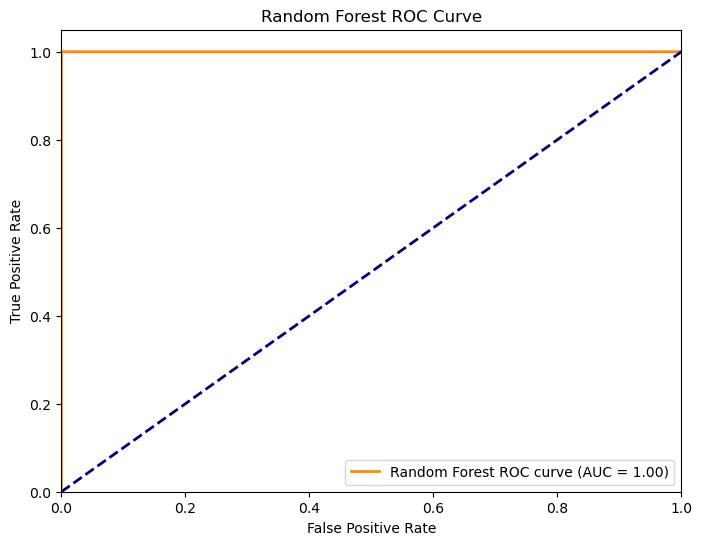

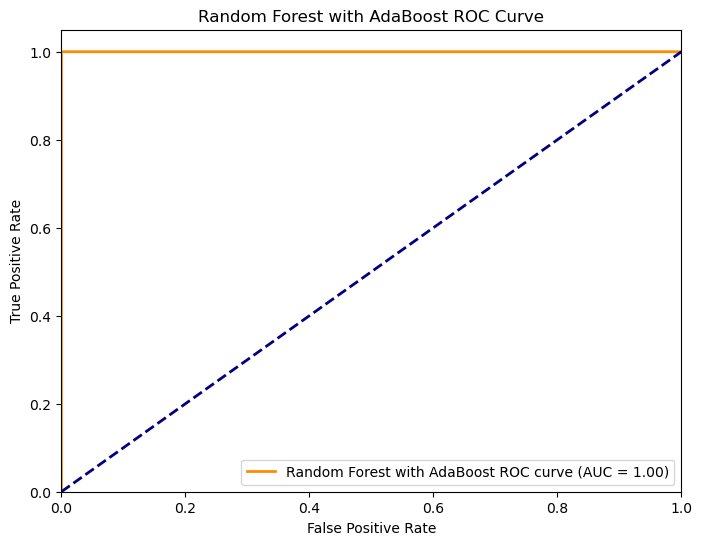

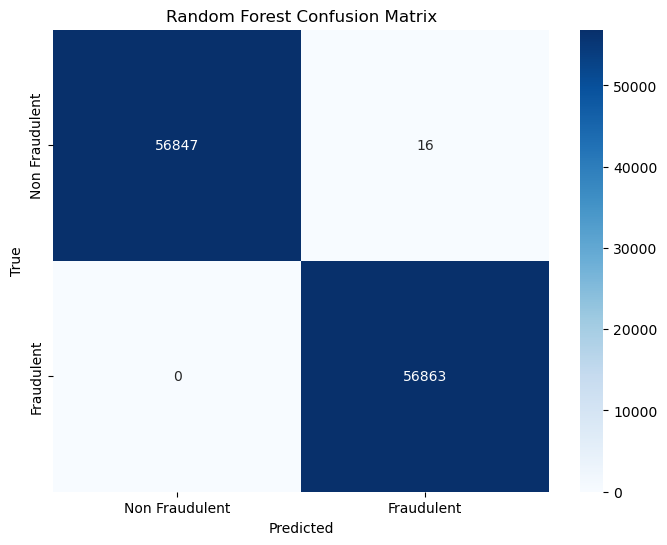

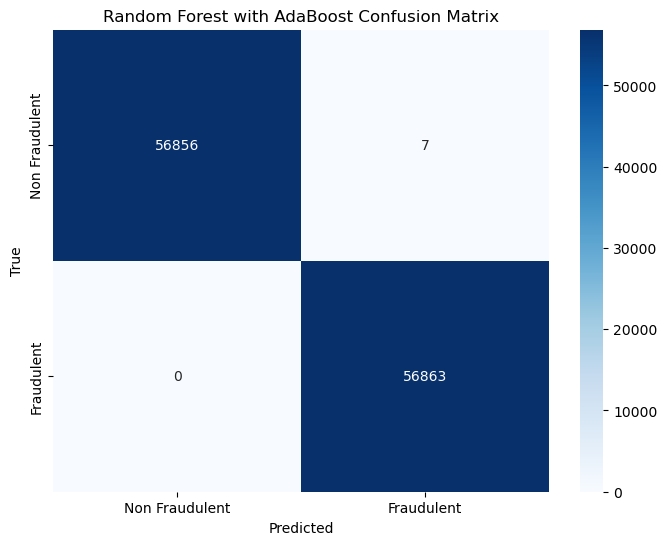

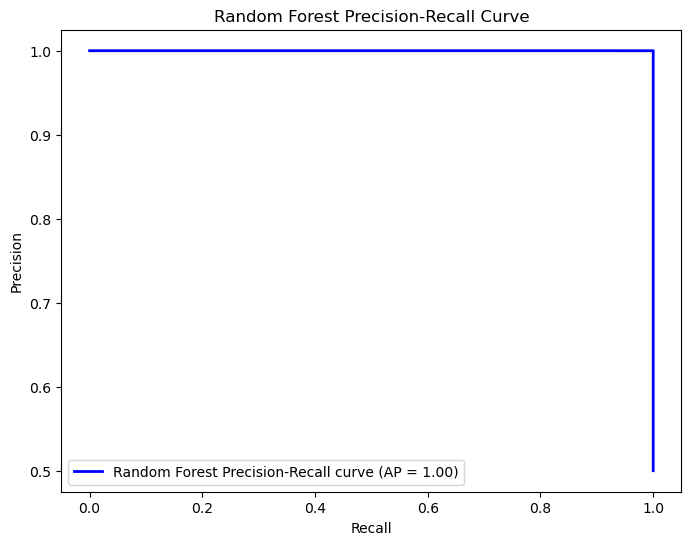

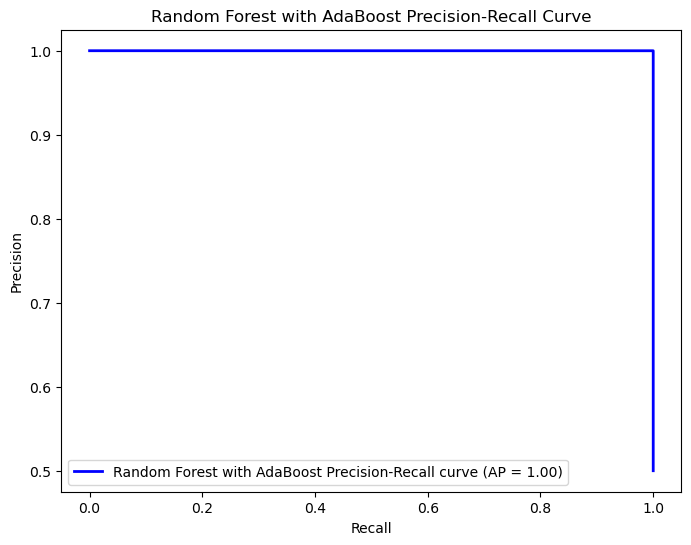

In [ ]:
# Train the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Making predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Show results
print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"MCC: {mcc_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")

# Apply AdaBoost to Random Forest
rf_base = RandomForestClassifier(random_state=42, n_estimators=10)  # Base model with fewer trees for AdaBoost
ada_rf = AdaBoostClassifier(estimator=rf_base, n_estimators=50, random_state=42)
ada_rf.fit(X_train, y_train)

# Making predictions
y_pred_ada_rf = ada_rf.predict(X_test)
y_proba_ada_rf = ada_rf.predict_proba(X_test)[:, 1]

# Calculate metrics for AdaBoost Random Forest
accuracy_ada_rf = accuracy_score(y_test, y_pred_ada_rf)
recall_ada_rf = recall_score(y_test, y_pred_ada_rf)
precision_ada_rf = precision_score(y_test, y_pred_ada_rf)
f1_ada_rf = f1_score(y_test, y_pred_ada_rf)
mcc_ada_rf = matthews_corrcoef(y_test, y_pred_ada_rf)
auc_ada_rf = roc_auc_score(y_test, y_proba_ada_rf)

# Show results for AdaBoost Random Forest
print("Random Forest with AdaBoost Metrics:")
print(f"Accuracy: {accuracy_ada_rf:.4f}")
print(f"Recall: {recall_ada_rf:.4f}")
print(f"Precision: {precision_ada_rf:.4f}")
print(f"F1-Score: {f1_ada_rf:.4f}")
print(f"MCC: {mcc_ada_rf:.4f}")
print(f"AUC: {auc_ada_rf:.4f}")

# Visualization 1: ROC and AUC curve
plot_roc_curve(rf, X_test, y_test, 'Random Forest')
plot_roc_curve(ada_rf, X_test, y_test, 'Random Forest with AdaBoost')

# Visualization 2: Confusion Matrix
plot_confusion_matrix(rf, X_test, y_test, 'Random Forest')
plot_confusion_matrix(ada_rf, X_test, y_test, 'Random Forest with AdaBoost')

# Visualization 3: Precision-recall curve
plot_precision_recall_curve(rf, X_test, y_test, 'Random Forest')
plot_precision_recall_curve(ada_rf, X_test, y_test, 'Random Forest with AdaBoost')


DECISION TREE

Decision Tree Metrics:
Accuracy: 0.9983
Recall: 0.9990
Precision: 0.9975
F1-Score: 0.9983
MCC: 0.9966
AUC: 0.9983


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Decision Tree with AdaBoost Metrics:
Accuracy: 0.9603
Recall: 0.9470
Precision: 0.9730
F1-Score: 0.9598
MCC: 0.9210
AUC: 0.9949


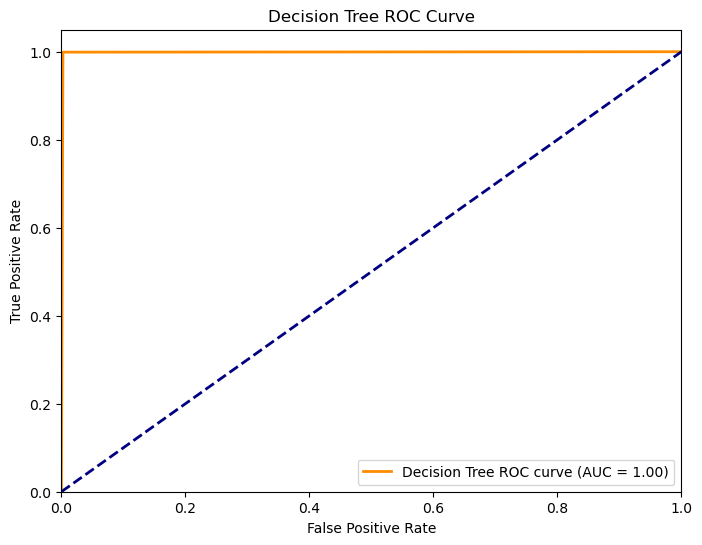

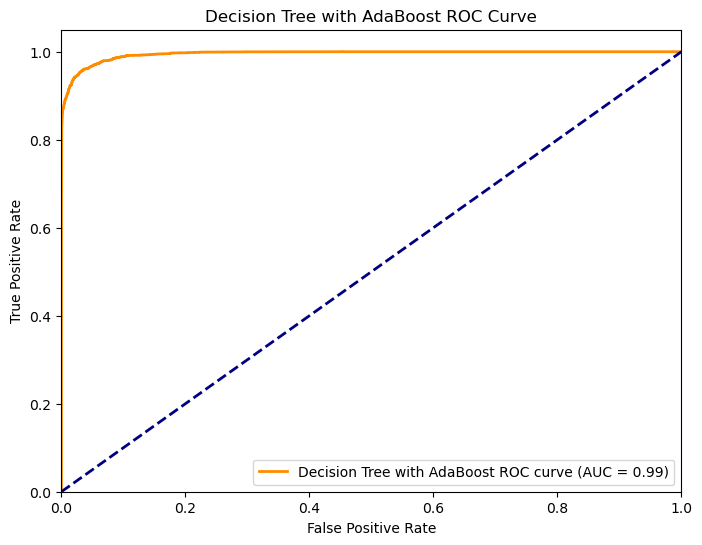

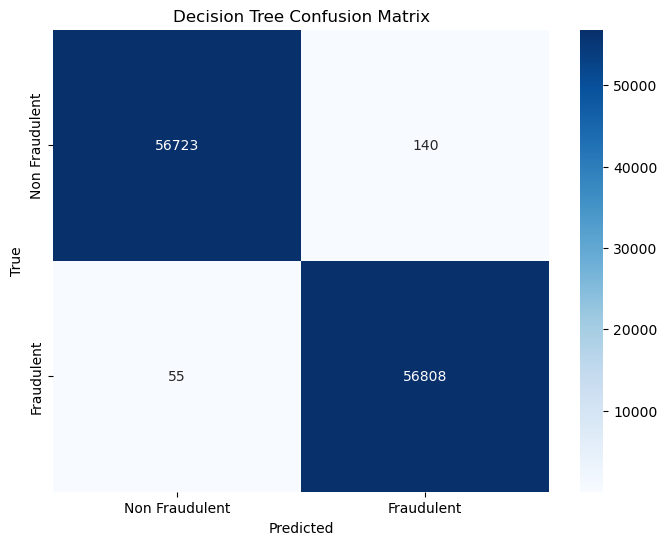

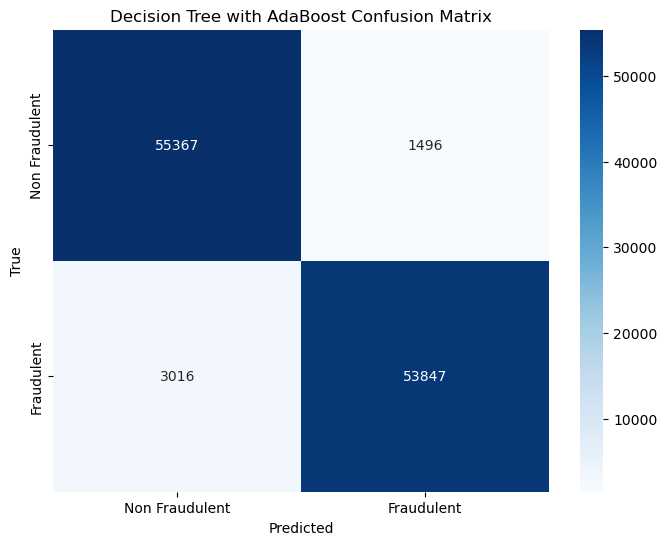

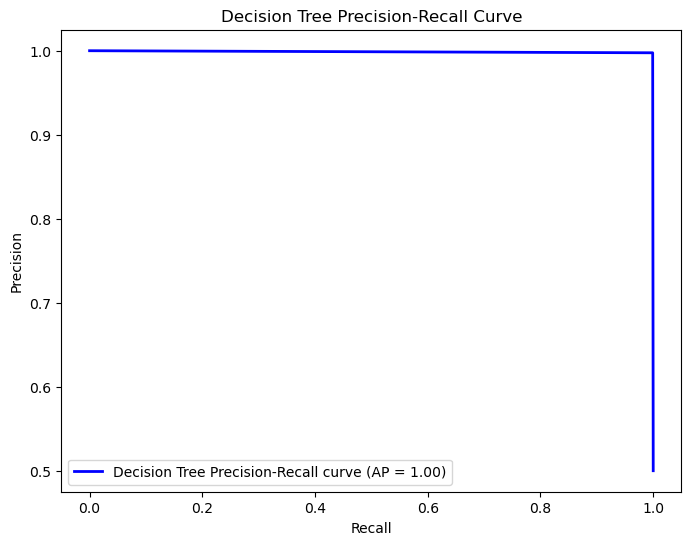

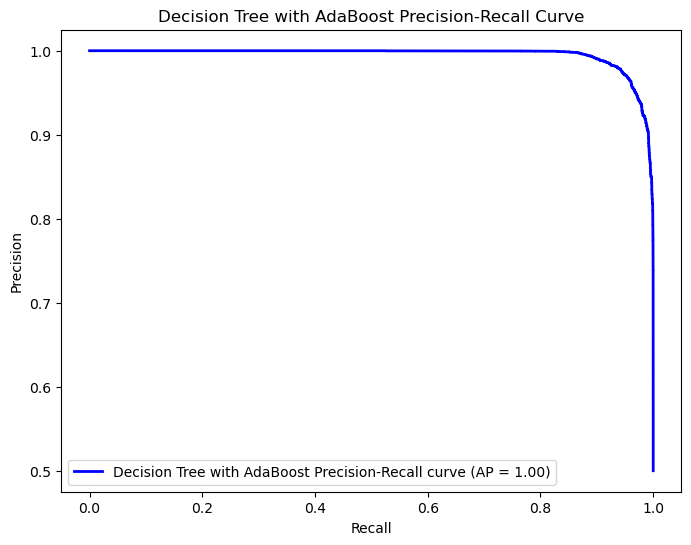

In [ ]:
# Train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Making predictions
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

# Show results for Decision Tree
print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"MCC: {mcc_dt:.4f}")
print(f"AUC: {auc_dt:.4f}")

# Apply AdaBoost to Decision Tree
dt_base = DecisionTreeClassifier(random_state=42, max_depth=1)  # A weak tree for AdaBoost
ada_dt = AdaBoostClassifier(estimator=dt_base, n_estimators=50, random_state=42)
ada_dt.fit(X_train, y_train)

# Making predictions with AdaBoost
y_pred_ada_dt = ada_dt.predict(X_test)
y_proba_ada_dt = ada_dt.predict_proba(X_test)[:, 1]

# Calculate metrics for AdaBoost Decision Tree
accuracy_ada_dt = accuracy_score(y_test, y_pred_ada_dt)
recall_ada_dt = recall_score(y_test, y_pred_ada_dt)
precision_ada_dt = precision_score(y_test, y_pred_ada_dt)
f1_ada_dt = f1_score(y_test, y_pred_ada_dt)
mcc_ada_dt = matthews_corrcoef(y_test, y_pred_ada_dt)
auc_ada_dt = roc_auc_score(y_test, y_proba_ada_dt)

# Show results for AdaBoost Decision Tree
print("Decision Tree with AdaBoost Metrics:")
print(f"Accuracy: {accuracy_ada_dt:.4f}")
print(f"Recall: {recall_ada_dt:.4f}")
print(f"Precision: {precision_ada_dt:.4f}")
print(f"F1-Score: {f1_ada_dt:.4f}")
print(f"MCC: {mcc_ada_dt:.4f}")
print(f"AUC: {auc_ada_dt:.4f}")

# Visualization 1: ROC Curve
def plot_roc_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(dt, X_test, y_test, 'Decision Tree')
plot_roc_curve(ada_dt, X_test, y_test, 'Decision Tree with AdaBoost')

# Visualization 2: Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraudulent', 'Fraudulent'], yticklabels=['Non Fraudulent', 'Fraudulent'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

plot_confusion_matrix(dt, X_test, y_test, 'Decision Tree')
plot_confusion_matrix(ada_dt, X_test, y_test, 'Decision Tree with AdaBoost')

# Visualization 3: Precision-recall curve
def plot_precision_recall_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'{model_name} Precision-Recall curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

plot_precision_recall_curve(dt, X_test, y_test, 'Decision Tree')
plot_precision_recall_curve(ada_dt, X_test, y_test, 'Decision Tree with AdaBoost')

EXTRA TREES

Extra Trees Metrics:
Accuracy: 0.9999, Recall: 1.0000, Precision: 0.9998, F1-Score: 0.9999, MCC: 0.9998, AUC: 1.0000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Extra Trees with AdaBoost Metrics:
Accuracy: 0.9999, Recall: 1.0000, Precision: 0.9998, F1-Score: 0.9999, MCC: 0.9998, AUC: 1.0000


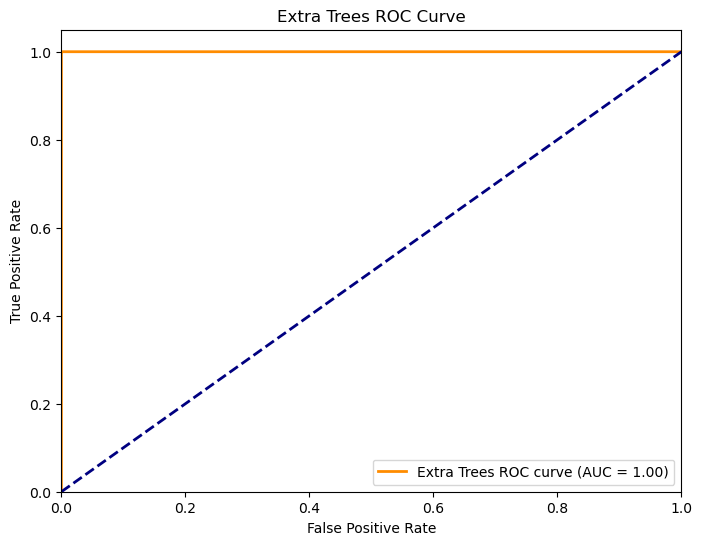

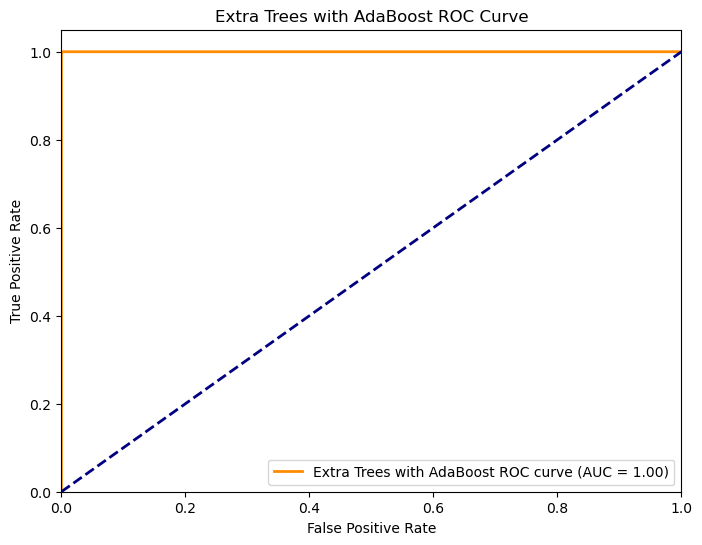

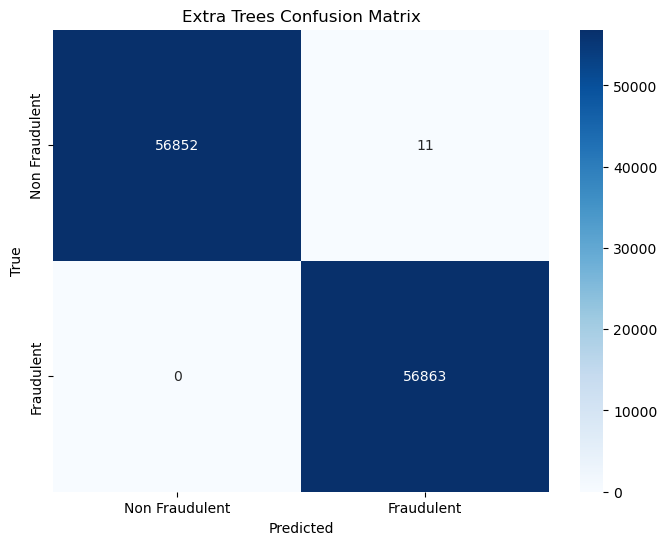

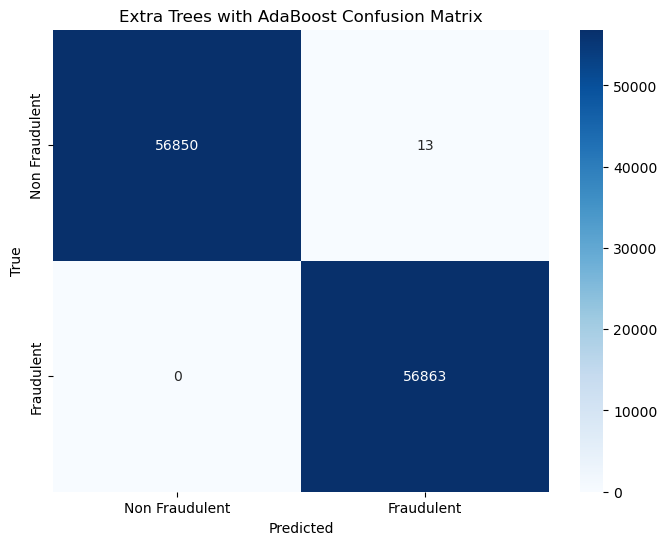

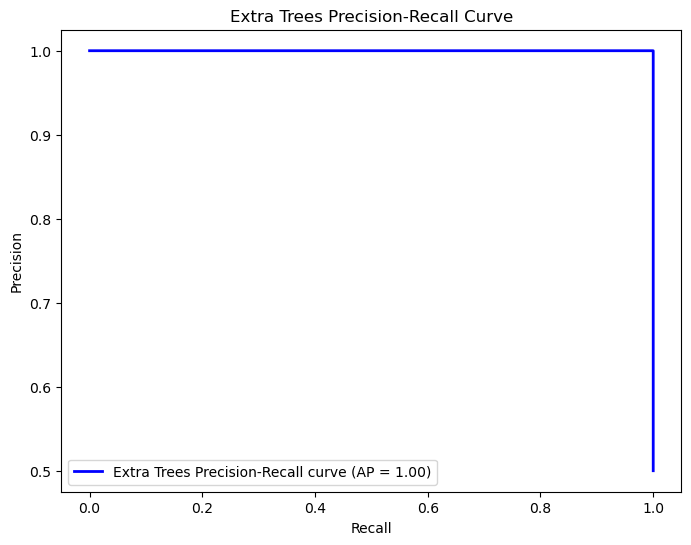

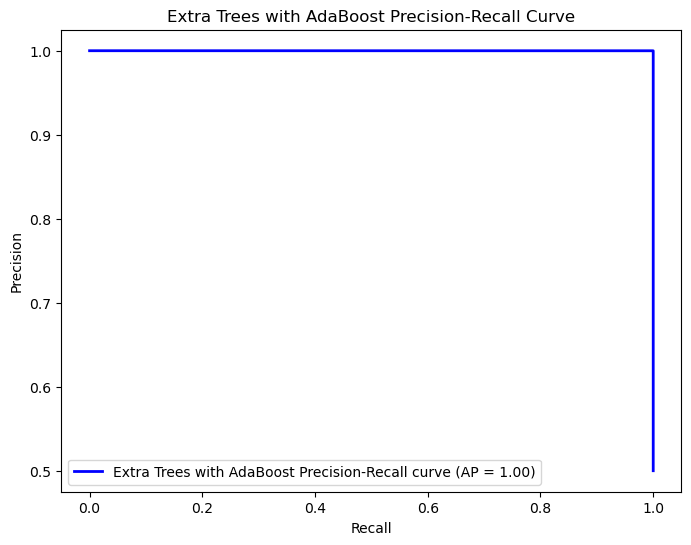

In [ ]:
# Train the Extra Trees model
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train, y_train)

# Making predictions
y_pred_et = et.predict(X_test)
y_proba_et = et.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_et = accuracy_score(y_test, y_pred_et)
recall_et = recall_score(y_test, y_pred_et)
precision_et = precision_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et)
mcc_et = matthews_corrcoef(y_test, y_pred_et)
auc_et = roc_auc_score(y_test, y_proba_et)

# Show results
print("Extra Trees Metrics:")
print(f"Accuracy: {accuracy_et:.4f}, Recall: {recall_et:.4f}, Precision: {precision_et:.4f}, F1-Score: {f1_et:.4f}, MCC: {mcc_et:.4f}, AUC: {auc_et:.4f}")

# Apply AdaBoost to Extra Trees
et_base = ExtraTreesClassifier(random_state=42, n_estimators=10)  # Base model with fewer trees for AdaBoost
ada_et = AdaBoostClassifier(estimator=et_base, n_estimators=50, random_state=42)
ada_et.fit(X_train, y_train)

# Making predictions
y_pred_ada_et = ada_et.predict(X_test)
y_proba_ada_et = ada_et.predict_proba(X_test)[:, 1]

# Calculate metrics for AdaBoost Extra Trees
accuracy_ada_et = accuracy_score(y_test, y_pred_ada_et)
recall_ada_et = recall_score(y_test, y_pred_ada_et)
precision_ada_et = precision_score(y_test, y_pred_ada_et)
f1_ada_et = f1_score(y_test, y_pred_ada_et)
mcc_ada_et = matthews_corrcoef(y_test, y_pred_ada_et)
auc_ada_et = roc_auc_score(y_test, y_proba_ada_et)

# Show results for AdaBoost Extra Trees
print("Extra Trees with AdaBoost Metrics:")
print(f"Accuracy: {accuracy_ada_et:.4f}, Recall: {recall_ada_et:.4f}, Precision: {precision_ada_et:.4f}, F1-Score: {f1_ada_et:.4f}, MCC: {mcc_ada_et:.4f}, AUC: {auc_ada_et:.4f}")

# Visualization 1: ROC and AUC curve
def plot_roc_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Visualization 2: Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraudulent', 'Fraudulent'], yticklabels=['Non Fraudulent', 'Fraudulent'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Visualisation 3: Courbe de précision-rappel
def plot_precision_recall_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'{model_name} Precision-Recall curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

# Plot the curves and matrices for the Extra Trees model
plot_roc_curve(et, X_test, y_test, 'Extra Trees')
plot_roc_curve(ada_et, X_test, y_test, 'Extra Trees with AdaBoost')

plot_confusion_matrix(et, X_test, y_test, 'Extra Trees')
plot_confusion_matrix(ada_et, X_test, y_test, 'Extra Trees with AdaBoost')

plot_precision_recall_curve(et, X_test, y_test, 'Extra Trees')
plot_precision_recall_curve(ada_et, X_test, y_test, 'Extra Trees with AdaBoost')

SVM

In [ ]:
# Train the SVM model
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

# Making predictions
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
mcc_svm = matthews_corrcoef(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

# Show results
print("SVM Metrics:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"MCC: {mcc_svm:.4f}")
print(f"AUC: {auc_svm:.4f}")

# Visualization 1: ROC Curve
def plot_roc_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(svm, X_test, y_test, 'SVM')

# Visualization 2: Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraudulent', 'Fraudulent'], yticklabels=['Non Fraudulent', 'Fraudulent'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

plot_confusion_matrix(svm, X_test, y_test, 'SVM')

# Visualization 3: Precision-recall curve
def plot_precision_recall_curve(model, X_test, y_test, model_name):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'{model_name} Precision-Recall curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

plot_precision_recall_curve(svm, X_test, y_test, 'SVM')

#SVM WITH ADABOOST
# Create a basic SVM
svm_base = SVC(probability=True, random_state=42)

# Apply AdaBoost to SVM
ada_svm = AdaBoostClassifier(estimator=svm_base, n_estimators=50, random_state=42)
ada_svm.fit(X_train, y_train)

# Making predictions
y_pred_ada_svm = ada_svm.predict(X_test)
y_proba_ada_svm = ada_svm.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_ada_svm = accuracy_score(y_test, y_pred_ada_svm)
recall_ada_svm = recall_score(y_test, y_pred_ada_svm)
precision_ada_svm = precision_score(y_test, y_pred_ada_svm)
f1_ada_svm = f1_score(y_test, y_pred_ada_svm)
mcc_ada_svm = matthews_corrcoef(y_test, y_pred_ada_svm)
auc_ada_svm = roc_auc_score(y_test, y_proba_ada_svm)

# Show results for AdaBoost with SVM
print("AdaBoost with SVM Metrics:")
print(f"Accuracy: {accuracy_ada_svm:.4f}")
print(f"Recall: {recall_ada_svm:.4f}")
print(f"Precision: {precision_ada_svm:.4f}")
print(f"F1-Score: {f1_ada_svm:.4f}")
print(f"MCC: {mcc_ada_svm:.4f}")
print(f"AUC: {auc_ada_svm:.4f}")

# Visualization 1: ROC Curve
plot_roc_curve(ada_svm, X_test, y_test, 'AdaBoost with SVM')

# Visualization 2: Confusion Matrix
plot_confusion_matrix(ada_svm, X_test, y_test, 'AdaBoost with SVM')

# Visualization 3: Precision-recall curve
plot_precision_recall_curve(ada_svm, X_test, y_test, 'AdaBoost with SVM')


XGBOOST

/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:59:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Metrics:
Accuracy: 0.9997
Recall: 1.0000
Precision: 0.9994
F1-Score: 0.9997
MCC: 0.9994
AUC: 1.0000


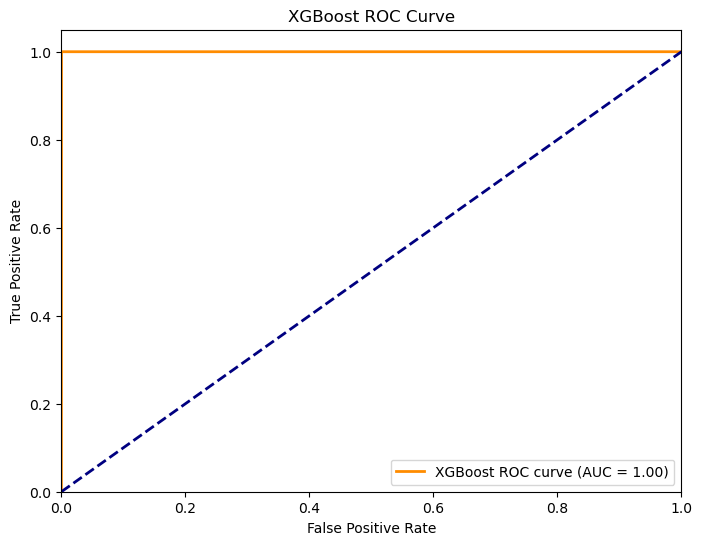

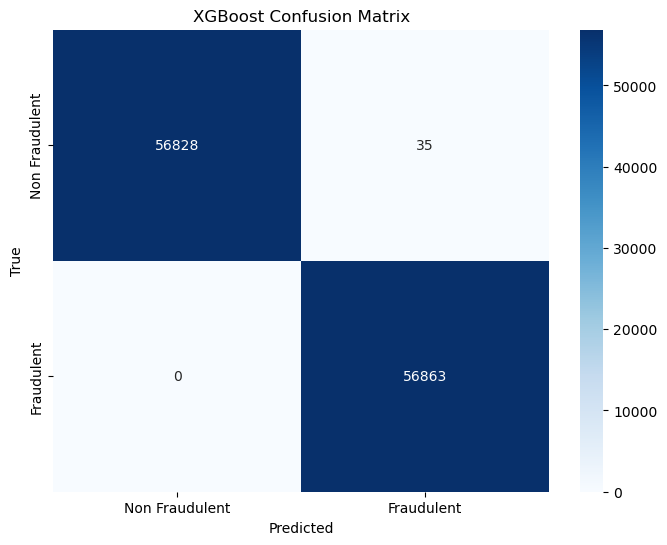

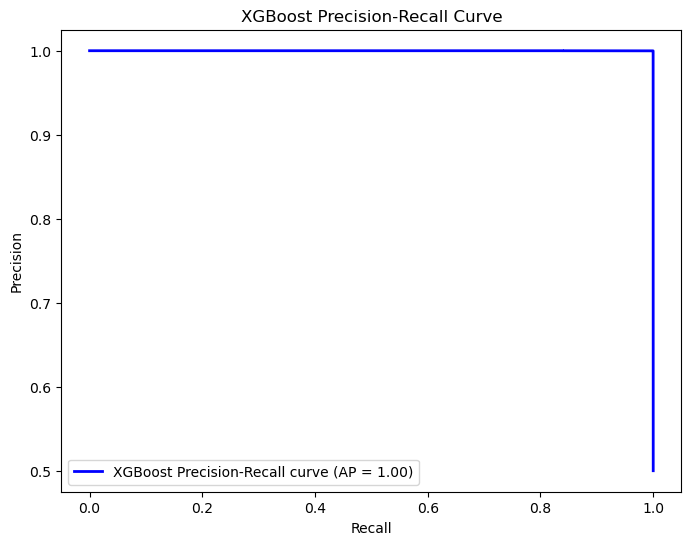

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:59:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:59:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:59:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/si

AdaBoost with XGBoost Metrics:
Accuracy: 0.5000
Recall: 0.0000
Precision: 0.0000
F1-Score: 0.0000
MCC: 0.0000
AUC: 0.5000


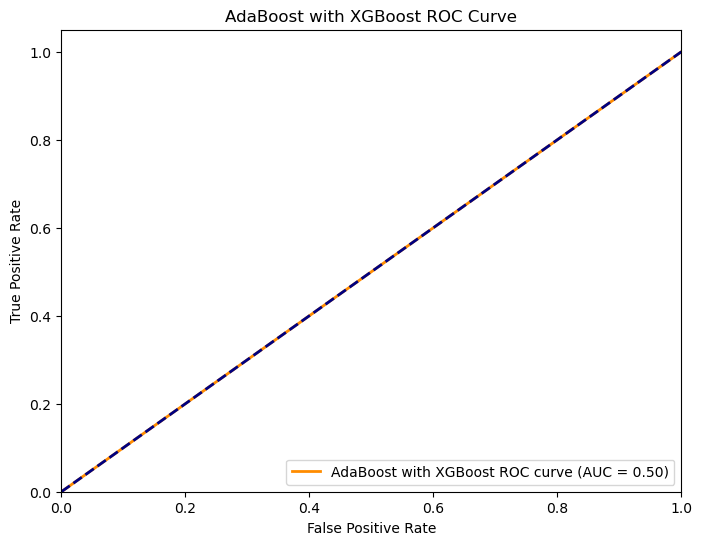

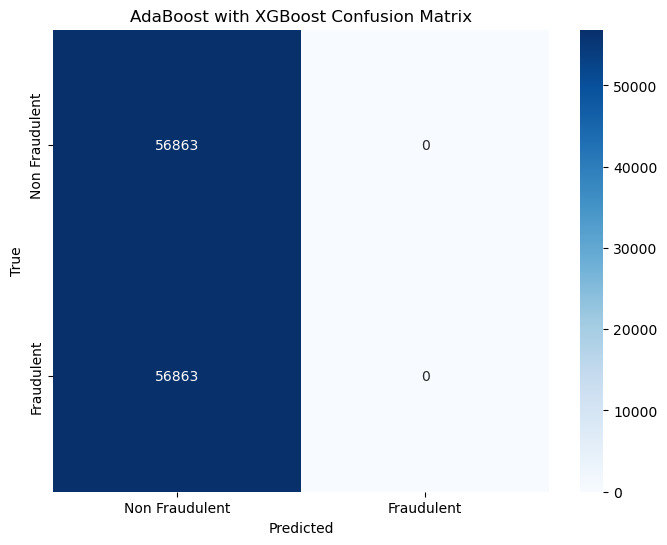

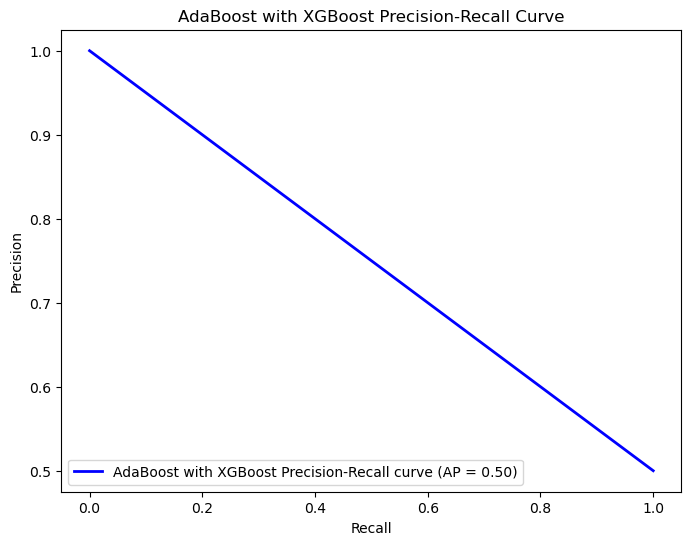

In [ ]:

# Train the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Making predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Show results
print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"MCC: {mcc_xgb:.4f}")
print(f"AUC: {auc_xgb:.4f}")

# Visualization 1: ROC Curve
plot_roc_curve(xgb_model, X_test, y_test, 'XGBoost')
# Visualization 2: Confusion Matrix
plot_confusion_matrix(xgb_model, X_test, y_test, 'XGBoost')

# Visualization 3: Precision-recall curve
plot_precision_recall_curve(xgb_model, X_test, y_test, 'XGBoost')



#XGBOOST WITH ADABOOST

# Create a basic XGBoost
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Apply AdaBoost to XGBoost
ada_xgb = AdaBoostClassifier(estimator=xgb_base, n_estimators=50, random_state=42)
ada_xgb.fit(X_train, y_train)

# Making predictions
y_pred_ada_xgb = ada_xgb.predict(X_test)
y_proba_ada_xgb = ada_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_ada_xgb = accuracy_score(y_test, y_pred_ada_xgb)
recall_ada_xgb = recall_score(y_test, y_pred_ada_xgb)
precision_ada_xgb = precision_score(y_test, y_pred_ada_xgb)
f1_ada_xgb = f1_score(y_test, y_pred_ada_xgb)
mcc_ada_xgb = matthews_corrcoef(y_test, y_pred_ada_xgb)
auc_ada_xgb = roc_auc_score(y_test, y_proba_ada_xgb)

# Show results for AdaBoost with XGBoost
print("AdaBoost with XGBoost Metrics:")
print(f"Accuracy: {accuracy_ada_xgb:.4f}")
print(f"Recall: {recall_ada_xgb:.4f}")
print(f"Precision: {precision_ada_xgb:.4f}")
print(f"F1-Score: {f1_ada_xgb:.4f}")
print(f"MCC: {mcc_ada_xgb:.4f}")
print(f"AUC: {auc_ada_xgb:.4f}")

# Visualization 1: ROC Curve
plot_roc_curve(ada_xgb, X_test, y_test, 'AdaBoost with XGBoost')

# Visualization 2: Confusion Matrix
plot_confusion_matrix(ada_xgb, X_test, y_test, 'AdaBoost with XGBoost')

# Visualization 3: Precision-recall curve
plot_precision_recall_curve(ada_xgb, X_test, y_test, 'AdaBoost with XGBoost')


In [ ]:
import pandas as pd

# Dictionary of metrics results
metrics = {
    'Model': [
        'Logistic Regression', 'Logistic Regression with AdaBoost',
        'Random Forest', 'Random Forest with AdaBoost',
        'Decision Tree', 'Decision Tree with AdaBoost',
        'Extra Trees', 'Extra Trees with AdaBoost'
    ],
    'Accuracy': [
        accuracy_lr, accuracy_ada_lr, accuracy_rf, accuracy_ada_rf, 
        accuracy_dt, accuracy_ada_dt, accuracy_et, accuracy_ada_et
    ],
    'Recall': [
        recall_lr, recall_ada_lr, recall_rf, recall_ada_rf, 
        recall_dt, recall_ada_dt, recall_et, recall_ada_et
    ],
    'Precision': [
        precision_lr, precision_ada_lr, precision_rf, precision_ada_rf, 
        precision_dt, precision_ada_dt, precision_et, precision_ada_et
    ],
    'F1-Score': [
        f1_lr, f1_ada_lr, f1_rf, f1_ada_rf, 
        f1_dt, f1_ada_dt, f1_et, f1_ada_et
    ],
    'MCC': [
        mcc_lr, mcc_ada_lr, mcc_rf, mcc_ada_rf, 
        mcc_dt, mcc_ada_dt, mcc_et, mcc_ada_et
    ],
    'AUC': [
        auc_lr, auc_ada_lr, auc_rf, auc_ada_rf, 
        auc_dt, auc_ada_dt, auc_et, auc_ada_et
    ]
}

# Create a DataFrame from the dictionary
df_metrics = pd.DataFrame(metrics)

# Show comparison table
print(df_metrics)


                               Model  Accuracy    Recall  Precision  F1-Score  \
0                Logistic Regression  0.948385  0.921689   0.973675  0.946969   
1  Logistic Regression with AdaBoost  0.939469  0.903927   0.973098  0.937238   
2                      Random Forest  0.999859  1.000000   0.999719  0.999859   
3        Random Forest with AdaBoost  0.999938  1.000000   0.999877  0.999938   
4                      Decision Tree  0.998285  0.999033   0.997542  0.998287   
5        Decision Tree with AdaBoost  0.960326  0.946960   0.972969  0.959788   
6                        Extra Trees  0.999903  1.000000   0.999807  0.999903   
7          Extra Trees with AdaBoost  0.999886  1.000000   0.999771  0.999886   

        MCC       AUC  
0  0.898050  0.989505  
1  0.881166  0.984615  
2  0.999719  0.999999  
3  0.999877  0.999994  
4  0.996572  0.998285  
5  0.920980  0.994949  
6  0.999807  1.000000  
7  0.999771  0.999974  
